In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("indian_roads_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20000, 24)


In [5]:
print(df.columns.tolist())

['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']


In [6]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [7]:
missing = df.isnull().sum()

print(missing[missing > 0])

festival    19885
dtype: int64


In [8]:
print(df["risk_score"].describe())

count    20000.000000
mean         0.437585
std          0.218130
min          0.100000
25%          0.250000
50%          0.450000
75%          0.600000
max          1.000000
Name: risk_score, dtype: float64


In [9]:
print(df["risk_score"].value_counts().sort_index())

risk_score
0.10    3149
0.20      12
0.25    2111
0.30    1664
0.35       7
0.40     269
0.45    6421
0.50     212
0.55      41
0.60    1304
0.65    2740
0.70       6
0.75      19
0.80    1508
0.85     298
0.90      11
0.95       1
1.00     227
Name: count, dtype: int64


In [10]:
features = [
    "city",
    "road_type",
    "weather",
    "visibility",
    "traffic_density",
    "date",
    "time",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour"
]

target = "risk_score"

X = df[features].copy()
y = df[target].copy()

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Input features:
['city', 'road_type', 'weather', 'visibility', 'traffic_density', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'is_peak_hour']

Target:
risk_score


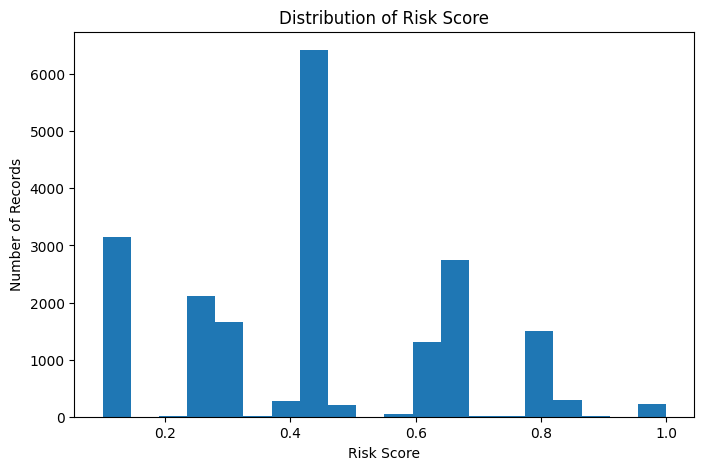

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["risk_score"], bins=20)

plt.xlabel("Risk Score")
plt.ylabel("Number of Records")
plt.title("Distribution of Risk Score")

plt.show()

In [12]:
print("Average Risk Score by Weather:")
print(df.groupby("weather")["risk_score"].mean())

print("\nAverage Risk Score by Visibility:")
print(df.groupby("visibility")["risk_score"].mean())

print("\nAverage Risk Score by Traffic Density:")
print(df.groupby("traffic_density")["risk_score"].mean())

print("\nAverage Risk Score by Peak Hour:")
print(df.groupby("is_peak_hour")["risk_score"].mean())

Average Risk Score by Weather:
weather
clear    0.236876
fog      0.589123
rain     0.488146
Name: risk_score, dtype: float64

Average Risk Score by Visibility:
visibility
high      0.236876
low       0.589176
medium    0.386067
Name: risk_score, dtype: float64

Average Risk Score by Traffic Density:
traffic_density
high      0.594754
low       0.339366
medium    0.367842
Name: risk_score, dtype: float64

Average Risk Score by Peak Hour:
is_peak_hour
0    0.382952
1    0.603779
Name: risk_score, dtype: float64


In [13]:
features = [
    "city",
    "road_type",
    "weather",
    "visibility",
    "traffic_density",
    "date",
    "time",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour"
]

X = df[features].copy()
y = df["risk_score"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 11)
y shape: (20000,)


In [14]:
print(X.dtypes)

city               object
road_type          object
weather            object
visibility         object
traffic_density    object
date               object
time               object
hour                int64
day_of_week        object
is_weekend          int64
is_peak_hour        int64
dtype: object


In [15]:
X["date"] = pd.to_datetime(X["date"])

X["year"] = X["date"].dt.year
X["month"] = X["date"].dt.month
X["day"] = X["date"].dt.day

X = X.drop("date", axis=1)

In [16]:
X = X.drop("time", axis=1)

In [17]:
from sklearn.preprocessing import OneHotEncoder

In [18]:
categorical_features = [
    "city",
    "road_type",
    "weather",
    "visibility",
    "traffic_density"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_data = encoder.fit_transform(X[categorical_features])

In [19]:
encoded_columns = encoder.get_feature_names_out(categorical_features)

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=X.index
)

In [20]:
X = X.drop(categorical_features, axis=1)

In [21]:
X_processed = pd.concat([X, encoded_df], axis=1)

In [22]:
print("Processed X shape:", X_processed.shape)
print(X_processed.head())

Processed X shape: (20000, 27)
   hour day_of_week  is_weekend  is_peak_hour  year  month  day  \
0     5      Sunday           1             0  2023     10   22   
1     4      Sunday           1             0  2023      5   21   
2    13   Wednesday           0             0  2024      7   10   
3    11      Sunday           1             0  2025      3   30   
4    16    Thursday           0             0  2024      1   25   

   city_Bangalore  city_Chandigarh  city_Chennai  ...  road_type_urban  \
0             0.0              0.0           0.0  ...              0.0   
1             0.0              0.0           0.0  ...              1.0   
2             0.0              0.0           0.0  ...              1.0   
3             0.0              1.0           0.0  ...              1.0   
4             0.0              0.0           1.0  ...              0.0   

   weather_clear  weather_fog  weather_rain  visibility_high  visibility_low  \
0            0.0          1.0           0

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16000, 27)
Testing data: (4000, 27)


In [25]:
from sklearn.preprocessing import LabelEncoder

day_encoder = LabelEncoder()

X_train["day_of_week"] = day_encoder.fit_transform(X_train["day_of_week"])
X_test["day_of_week"] = day_encoder.transform(X_test["day_of_week"])

print("day_of_week converted successfully!")
print(X_train["day_of_week"].head())

day_of_week converted successfully!
5894    2
3728    6
8958    0
7671    6
5999    5
Name: day_of_week, dtype: int64


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [27]:
print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 27)
X_test: (4000, 27)
y_train: (16000,)
y_test: (4000,)


In [28]:
features = [
    "city",
    "road_type",
    "weather",
    "visibility",
    "traffic_density",
    "date",
    "time",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour"
]

target = "risk_score"

X = df[features].copy()
y = df[target].copy()

print("Features selected successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features selected successfully!
X shape: (20000, 11)
y shape: (20000,)


In [29]:
X["date"] = pd.to_datetime(X["date"])

X["year"] = X["date"].dt.year
X["month"] = X["date"].dt.month
X["day"] = X["date"].dt.day

X = X.drop("date", axis=1)

print("Date processing completed!")

Date processing completed!


In [30]:
X = X.drop("time", axis=1)

print("Time column removed!")

Time column removed!


In [31]:
categorical_features = [
    "city",
    "road_type",
    "weather",
    "visibility",
    "traffic_density",
    "day_of_week"
]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16000, 12)
Testing data: (4000, 12)


In [33]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

print("Categorical encoding completed!")

Categorical encoding completed!


In [34]:
encoded_columns = encoder.get_feature_names_out(
    categorical_features
)

train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

In [35]:
X_train = X_train.drop(categorical_features, axis=1)
X_test = X_test.drop(categorical_features, axis=1)

print("Original categorical columns removed!")

Original categorical columns removed!


In [36]:
X_train_processed = pd.concat(
    [X_train, train_encoded_df],
    axis=1
)

X_test_processed = pd.concat(
    [X_test, test_encoded_df],
    axis=1
)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (16000, 33)
Processed testing shape: (4000, 33)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print("Scaling completed!")

Scaling completed!


In [38]:
print("Final training data shape:", X_train_scaled.shape)
print("Final testing data shape:", X_test_scaled.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nData type:", X_train_scaled.dtype)

Final training data shape: (16000, 33)
Final testing data shape: (4000, 33)
Training target shape: (16000,)
Testing target shape: (4000,)

Data type: float64


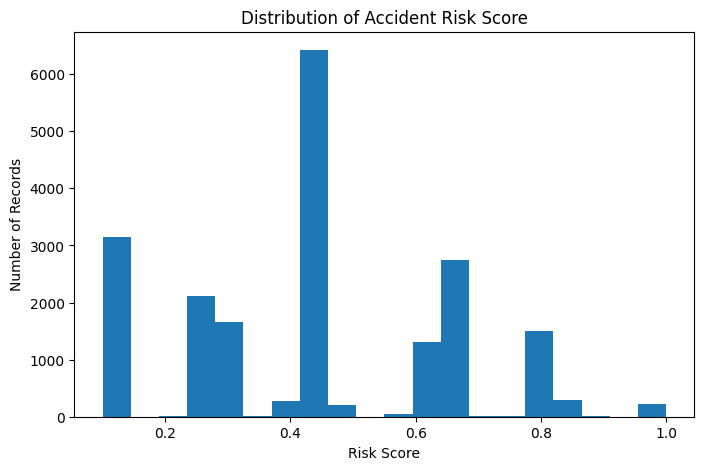

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["risk_score"], bins=20)

plt.xlabel("Risk Score")
plt.ylabel("Number of Records")
plt.title("Distribution of Accident Risk Score")

plt.show()

weather
clear    0.236876
fog      0.589123
rain     0.488146
Name: risk_score, dtype: float64


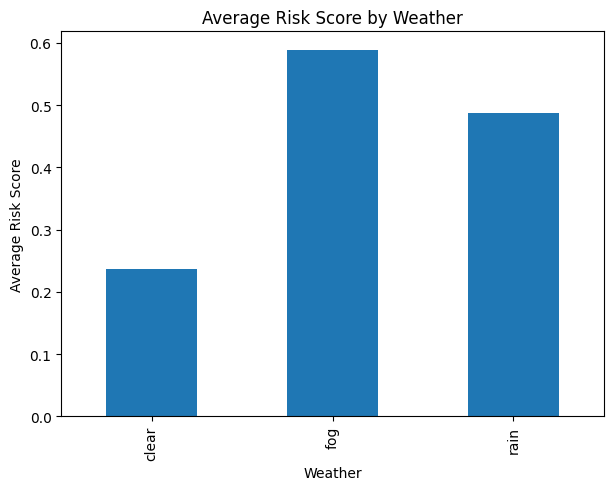

In [40]:
weather_risk = df.groupby("weather")["risk_score"].mean()

print(weather_risk)

plt.figure(figsize=(7, 5))

weather_risk.plot(kind="bar")

plt.xlabel("Weather")
plt.ylabel("Average Risk Score")
plt.title("Average Risk Score by Weather")

plt.show()

visibility
high      0.236876
low       0.589176
medium    0.386067
Name: risk_score, dtype: float64


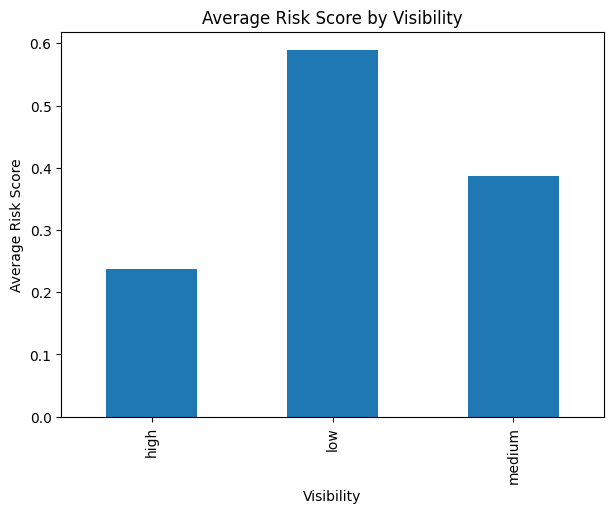

In [41]:
visibility_risk = df.groupby("visibility")["risk_score"].mean()

print(visibility_risk)

plt.figure(figsize=(7, 5))

visibility_risk.plot(kind="bar")

plt.xlabel("Visibility")
plt.ylabel("Average Risk Score")
plt.title("Average Risk Score by Visibility")

plt.show()

traffic_density
high      0.594754
low       0.339366
medium    0.367842
Name: risk_score, dtype: float64


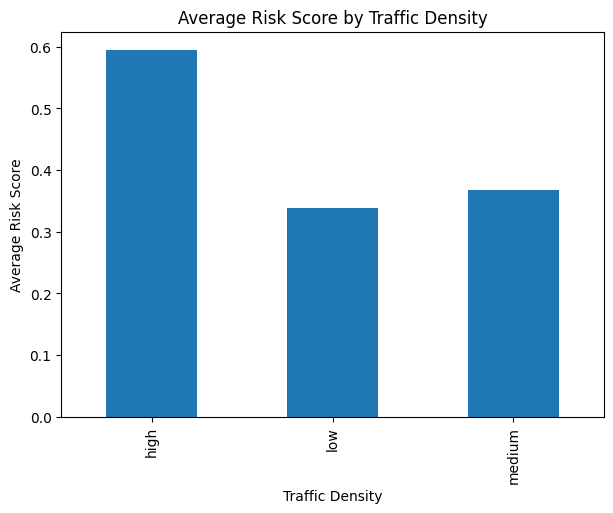

In [42]:
traffic_risk = df.groupby("traffic_density")["risk_score"].mean()

print(traffic_risk)

plt.figure(figsize=(7, 5))

traffic_risk.plot(kind="bar")

plt.xlabel("Traffic Density")
plt.ylabel("Average Risk Score")
plt.title("Average Risk Score by Traffic Density")

plt.show()

hour
0     0.355833
1     0.352328
2     0.341216
3     0.348119
4     0.355031
5     0.413241
6     0.390304
7     0.400191
8     0.608304
9     0.594911
10    0.609569
11    0.407967
12    0.397748
13    0.390945
14    0.393795
15    0.398397
16    0.379987
17    0.604994
18    0.613366
19    0.591429
20    0.391110
21    0.393494
22    0.383353
23    0.402788
Name: risk_score, dtype: float64


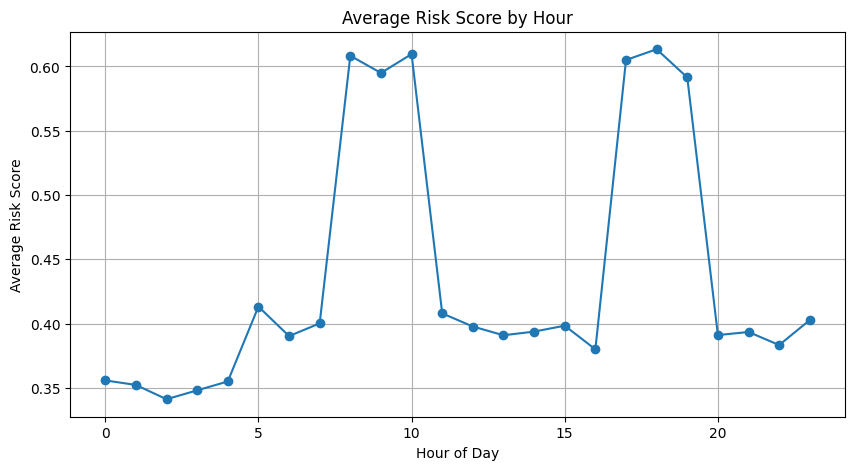

In [43]:
hour_risk = df.groupby("hour")["risk_score"].mean()

print(hour_risk)

plt.figure(figsize=(10, 5))

hour_risk.plot(kind="line", marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Risk Score")
plt.title("Average Risk Score by Hour")

plt.grid()
plt.show()

is_peak_hour
0    0.382952
1    0.603779
Name: risk_score, dtype: float64


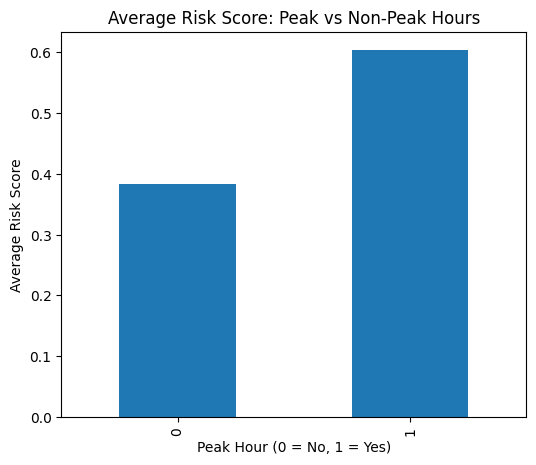

In [44]:
peak_risk = df.groupby("is_peak_hour")["risk_score"].mean()

print(peak_risk)

plt.figure(figsize=(6, 5))

peak_risk.plot(kind="bar")

plt.xlabel("Peak Hour (0 = No, 1 = Yes)")
plt.ylabel("Average Risk Score")
plt.title("Average Risk Score: Peak vs Non-Peak Hours")

plt.show()

In [45]:
numeric_columns = [
    "hour",
    "is_weekend",
    "is_peak_hour",
    "lanes",
    "temperature"
]

correlation = df[numeric_columns + ["risk_score"]].corr()

print(correlation["risk_score"].sort_values(ascending=False))

risk_score      1.000000
is_peak_hour    0.436848
hour            0.122017
is_weekend      0.004033
lanes          -0.001721
temperature    -0.001885
Name: risk_score, dtype: float64
